In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. CHARGEMENT ET PRÉPARATION ---
print("Chargement des données...")
df = pd.read_csv('data_ready_to_use.csv')

target_col = "LIT_002_FILTER_WATER_STG_TNK"


Chargement des données...


Chargement des données...
Création d'un échantillon de 15000 lignes pour l'optimisation...

--- DÉBUT DU GRID SEARCH (Optimisation) ---
Optimisation de KNN...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  -> Meilleur R² KNN: 0.6644 (en 16.9s)
  -> Meilleurs Params: {'n_neighbors': 5, 'weights': 'distance'}
Optimisation de SVM...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  -> Meilleur R² SVM: 0.5826 (en 849.0s)
  -> Meilleurs Params: {'C': 100, 'epsilon': 0.2}

Génération des graphiques de performance...


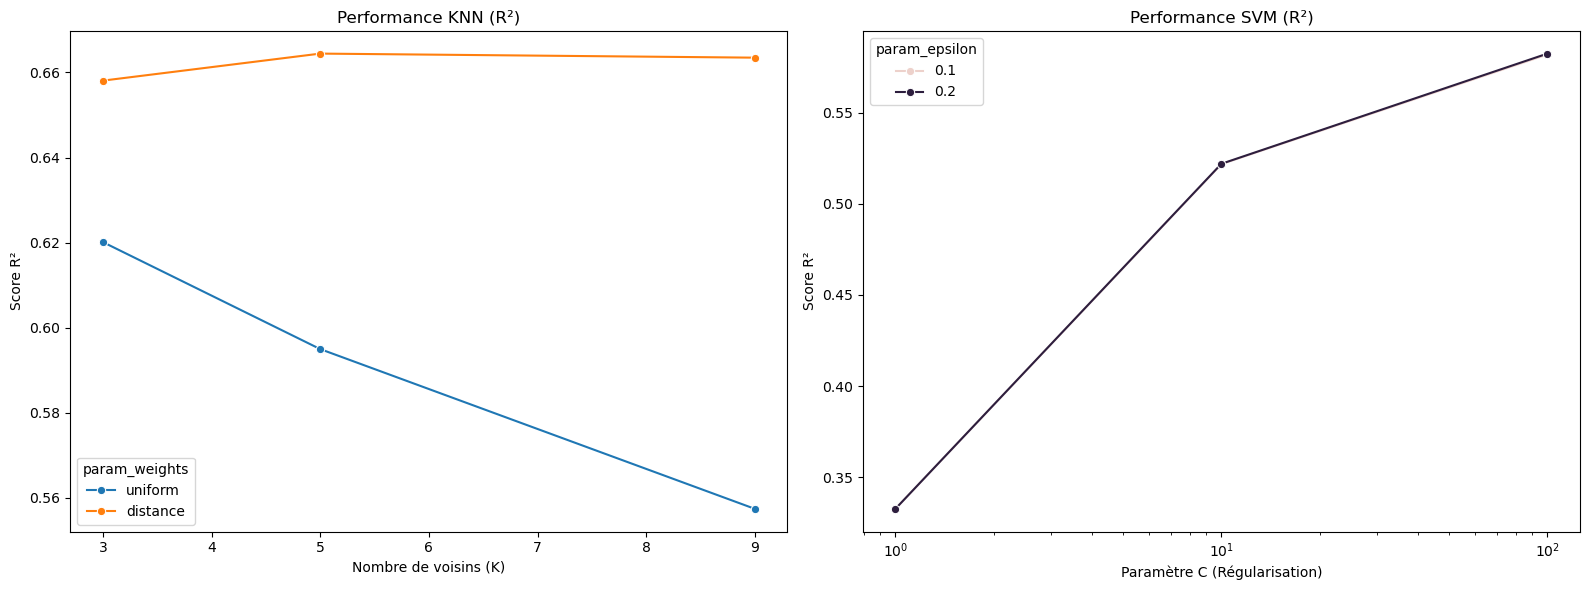

🏆 LE GAGNANT EST : KNN
Avec les paramètres : {'n_neighbors': 5, 'weights': 'distance'}

Lancement de l'entraînement FINAL sur tout le dataset (449002 lignes)...
Entraînement terminé en 0.03 secondes.

Évaluation finale sur le jeu de test...
--- RÉSULTATS FINAUX (KNN) ---
R² Score : 0.9532
MAE      : 1.2410
RMSE     : 2.2514


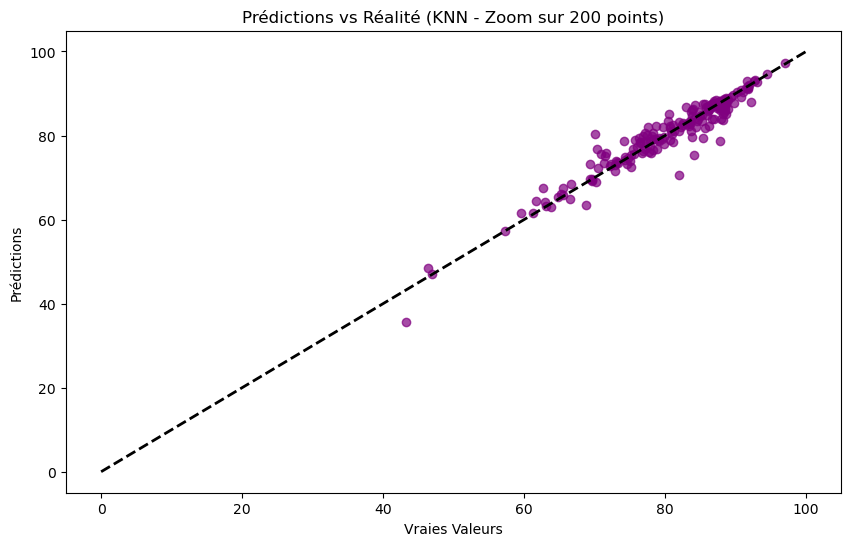


Sauvegarde du modèle et du scaler...
✅ Sauvegarde terminée : 'best_model_tuned.pkl' et 'scaler_tuned.pkl'


In [1]:

# Séparation X et y
try:
    target_index = df.columns.get_loc(target_col)
    X = df.iloc[:, :target_index] # Colonnes avant la cible
    y = df[target_col]
except KeyError:
    print(f"Erreur : Cible '{target_col}' introuvable.")
    exit()

# Scaling (Indispensable pour SVM et KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. ÉCHANTILLONNAGE POUR GRID SEARCH (SECURITE RAM) ---
# SVM sur 500k lignes prendrait des jours. On optimise sur 15k lignes.
SAMPLE_SIZE = 15000 
print(f"Création d'un échantillon de {SAMPLE_SIZE} lignes pour l'optimisation...")

# On prend des indices au hasard
indices_sample = np.random.choice(X.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_scaled[indices_sample]
y_sample = y.iloc[indices_sample]

# --- 3. DÉFINITION DES GRILLES DE PARAMÈTRES ---
model_params = {
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 9],
            'weights': ['uniform', 'distance']
        }
    },
    'SVM': {
        'model': SVR(), # Support Vector Regressor
        'params': {
            'C': [1, 10, 100],      # Pénalité
            'epsilon': [0.1, 0.2]   # Marge d'erreur tolérée
            # Note : On garde le kernel 'rbf' par défaut
        }
    }
}

results_data = [] # Pour stocker les scores et dessiner les graphes
best_global_score = -np.inf
best_global_model_name = ""
best_global_params = {}
best_global_estimator = None

# --- 4. EXÉCUTION DU GRID SEARCH ---
print("\n--- DÉBUT DU GRID SEARCH (Optimisation) ---")

for model_name, mp in model_params.items():
    print(f"Optimisation de {model_name}...")
    start = time.time()
    
    # GridSearchCV
    # n_jobs=-1 utilise tous les cœurs (Attention, SVR ne supporte pas toujours n_jobs selon le backend)
    jobs = -1 if model_name == 'KNN' else 1 
    
    clf = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='r2', n_jobs=jobs, verbose=1)
    clf.fit(X_sample, y_sample)
    
    end = time.time()
    print(f"  -> Meilleur R² {model_name}: {clf.best_score_:.4f} (en {end-start:.1f}s)")
    print(f"  -> Meilleurs Params: {clf.best_params_}")
    
    # Stockage pour le graphique
    results_data.append({
        'model': model_name,
        'cv_results': pd.DataFrame(clf.cv_results_)
    })
    
    # Comparaison pour trouver le grand gagnant
    if clf.best_score_ > best_global_score:
        best_global_score = clf.best_score_
        best_global_model_name = model_name
        best_global_params = clf.best_params_
        best_global_estimator = clf.best_estimator_ # C'est le modèle configuré mais entraîné sur le sample

# --- 5. VISUALISATION DES RÉSULTATS (GRAPHES) ---
print("\nGénération des graphiques de performance...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : KNN
knn_res = next(item for item in results_data if item["model"] == "KNN")['cv_results']
sns.lineplot(data=knn_res, x='param_n_neighbors', y='mean_test_score', hue='param_weights', marker='o', ax=axes[0])
axes[0].set_title("Performance KNN (R²)")
axes[0].set_xlabel("Nombre de voisins (K)")
axes[0].set_ylabel("Score R²")

# Graphe 2 : SVM
svm_res = next(item for item in results_data if item["model"] == "SVM")['cv_results']
# On plot C vs Score, avec des lignes différentes pour epsilon
sns.lineplot(data=svm_res, x='param_C', y='mean_test_score', hue='param_epsilon', marker='o', ax=axes[1])
axes[1].set_title("Performance SVM (R²)")
axes[1].set_xlabel("Paramètre C (Régularisation)")
axes[1].set_xscale('log') # Echelle log car C varie de 1 à 100
axes[1].set_ylabel("Score R²")

plt.tight_layout()
plt.show()

# --- 6. ENTRAÎNEMENT FINAL (SUR TOUT LE DATASET) ---
print("="*60)
print(f"🏆 LE GAGNANT EST : {best_global_model_name}")
print(f"Avec les paramètres : {best_global_params}")
print("="*60)

print(f"\nLancement de l'entraînement FINAL sur tout le dataset ({len(X)} lignes)...")
# Split final Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Création du modèle final avec les meilleurs paramètres trouvés
if best_global_model_name == 'KNN':
    final_model = KNeighborsRegressor(**best_global_params, n_jobs=-1)
else:
    # Attention, SVR sur 400k lignes peut être lent
    print("⚠️ Attention : SVR sur tout le dataset peut être long...")
    final_model = SVR(**best_global_params)

start_final = time.time()
final_model.fit(X_train, y_train)
print(f"Entraînement terminé en {time.time() - start_final:.2f} secondes.")

# --- 7. SCORING ET SAUVEGARDE ---
print("\nÉvaluation finale sur le jeu de test...")
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- RÉSULTATS FINAUX ({best_global_model_name}) ---")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# Visualisation Prédiction vs Réalité (Sur un sous-ensemble pour lisibilité)
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:200], y_pred[:200], alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ligne parfaite
plt.xlabel("Vraies Valeurs")
plt.ylabel("Prédictions")
plt.title(f"Prédictions vs Réalité ({best_global_model_name} - Zoom sur 200 points)")
plt.show()

print("\nSauvegarde du modèle et du scaler...")
joblib.dump(final_model, 'best_model_tuned.pkl')
joblib.dump(scaler, 'scaler_tuned.pkl')
print("✅ Sauvegarde terminée : 'best_model_tuned.pkl' et 'scaler_tuned.pkl'")

Chargement du modèle optimisé...
✅ Modèle chargé : KNeighborsRegressor
Simulation avec 23 variables d'entrée...
Démarrage de l'usine virtuelle...


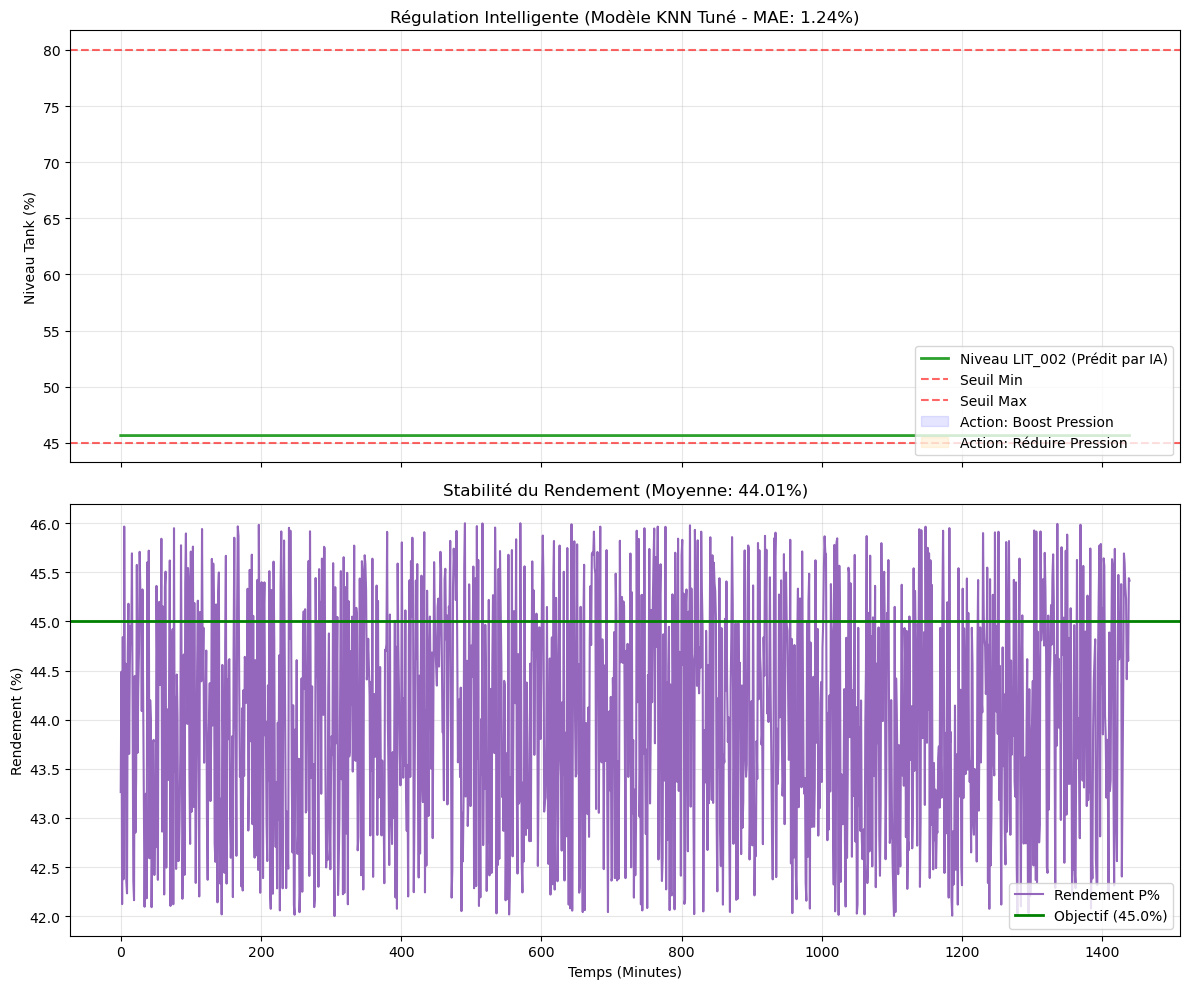

Simulation terminée avec succès.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import joblib

# ==============================================================================
# 1. CHARGEMENT DU "CERVEAU" (MODÈLE + SCALER)
# ==============================================================================
print("1. Chargement de l'intelligence artificielle...")
try:
    # On charge le meilleur modèle et son scaler associé
    # (Assurez-vous que les fichiers sont dans le même dossier)
    knn_model = joblib.load('best_model_tuned.pkl') 
    scaler = joblib.load('scaler_tuned.pkl')
    
    # On récupère les noms exacts des colonnes et leurs MOYENNES historiques
    cols_model = scaler.feature_names_in_
    valeurs_moyennes = dict(zip(cols_model, scaler.mean_))
    
    print(f"✅ Modèle chargé avec succès ({len(cols_model)} features).")
    print("✅ Moyennes historiques chargées (pour combler les trous de simulation).")
    
except FileNotFoundError:
    print("❌ ERREUR CRITIQUE : Fichiers .pkl introuvables.")
    print("   Veuillez relancer l'entraînement et la sauvegarde (étape précédente).")
    exit()



In [13]:
#Gant diagram would be nice for each filter backwash

## 💧 Stratégie Backwash – Raisonnement et Features

Dans ce notebook, nous construisons une **stratégie intelligente de backwash** pour le système de filtration HMMF, en utilisant les données du dataset. L’objectif est de décider **quand et quels filtres nettoyer**, en respectant les contraintes réelles du procédé.

### 🔹 Principes généraux

1. **Mesurer l’état des filtres**

   * Les colonnes `PDIT_001A…J` représentent la **pression différentielle à travers chaque filtre**.
   * Plus la ∆P est élevée, plus le filtre est encrassé.
   * Nous créons un **indice global d’encrassement** et un **indice de déséquilibre** pour savoir si certains filtres sont plus sales que d’autres.

2. **Mesurer l’impact sur la production**

   * Les débits d’entrée `FIT_001A…J` permettent d’évaluer si l’encrassement réduit effectivement la production.
   * Un indice combinant ∆P et débit identifie les situations critiques.

3. **Considérer le niveau du réservoir et la capacité backwash**

   * `LIT_002_FILTER_WATER_STG_TNK` : niveau du réservoir principal (contrôle prioritaire).
   * `LIT_003 OF HMMF BACKWASH STORAGE TANK` : capacité disponible pour le backwash.
   * Ces colonnes **ne déclenchent jamais le backwash seules**, mais autorisent ou bloquent l’action.

### 🔹 Décision backwash

Le professeur impose les règles suivantes :

| Niveau réservoir | Action possible           | Notes                                                  |
| ---------------- | ------------------------- | ------------------------------------------------------ |
| < 40 %           | Aucun backwash            | Priorité au stockage                                   |
| 40–60 %          | Backwash partiel          | Seuls les filtres les plus encrassés sont nettoyés     |
| ≥ 60 %           | Backwash complet possible | Tous les filtres peuvent être backwashés si nécessaire |

### 🔹 Fonctionnement de la stratégie

1. Calcul de **3 indices physiques** :

   * `INDICE_ENCRASSEMENT_HMMF` → état global des filtres
   * `INDICE_IMPACT_PRODUCTION` → urgence réelle selon débit
   * `INDICE_DESEQUILIBRE_FILTRES` → permet de décider un backwash partiel

2. Application de **règles logiques** pour décider :

   * Pas de backwash, retardé, partiel ou complet

3. Sélection des filtres à backwasher dans le cas **partiel** :

   * On choisit les filtres les **plus encrassés** (top 30 % de ∆P)


In [16]:
import numpy as np


PDIT_COLS = [
    "PDIT_001A_DIFF PRESSURE ACROSS HMMF-A",
    "PDIT_001B_DIFF PRESSURE ACROSS HMMF-B",
    "PDIT_001C_DIFF PRESSURE ACROSS HMMF-C",
    "PDIT_001D_DIFF PRESSURE ACROSS HMMF-D",
    "PDIT_001E_DIFF PRESSURE ACROSS HMMF-E",
    "PDIT_001F_DIFF PRESSURE ACROSS HMMF-F",
    "PDIT_001G_DIFF PRESSURE ACROSS HMMF-G",
    "PDIT_001H_DIFF PRESSURE ACROSS HMMF-H",
    "PDIT_001I_DIFF PRESSURE ACROSS HMMF-I",
    "PDIT_001J_DIFF PRESSURE ACROSS HMMF-J",
]

FIT_COLS = [
    "FIT_001A_FLOW AT INLET HMMF-A",
    "FIT_001B_FLOW AT INLET HMMF-B",
    "FIT_001C_FLOW AT INLET HMMF-C",
    "FIT_001D_FLOW AT INLET HMMF-D",
    "FIT_001E_FLOW AT INLET HMMF-E",
    "FIT_001F_FLOW AT INLET HMMF-F",
    "FIT_001G_FLOW AT INLET HMMF-G",
    "FIT_001H_FLOW AT INLET HMMF-H",
    "FIT_001I_FLOW AT INLET HMMF-I",
    "FIT_001J_FLOW AT INLET HMMF-J",
]


In [18]:
# Indice 1 — Encrassement global HMMF
df["INDICE_ENCRASSEMENT_HMMF"] = df[PDIT_COLS].mean(axis=1)


# Indice 2 — Impact sur la production
df["DEBIT_ENTREE_HMMF"] = df[FIT_COLS].mean(axis=1)

df["INDICE_IMPACT_PRODUCTION"] = (
    df["INDICE_ENCRASSEMENT_HMMF"] / (df["DEBIT_ENTREE_HMMF"] + 1e-6)
)


# Indice 3 — Déséquilibre entre filtres
df["INDICE_DESEQUILIBRE_FILTRES"] = df[PDIT_COLS].std(axis=1)




| Décision          | Code numérique |
| ----------------- | -------------- |
| PAS_DE_BACKWASH   | 0              |
| RETARDER_BACKWASH | 1              |
| BACKWASH_PARTIEL  | 2              |
| BACKWASH_COMPLET  | 3              |


In [29]:
# Décision backwash (règles du prof respectées)
#  encodée numériquement
def decision_backwash_numeric(row):
    niveau_reservoir = row["LIT_002_FILTER_WATER_STG_TNK"]
    capacite_backwash = row["LIT_003 OF HMMF BACKWASH STORAGE TANK"]
    encrassement = row["INDICE_ENCRASSEMENT_HMMF"]
    desequilibre = row["INDICE_DESEQUILIBRE_FILTRES"]

    # < 40 % → priorité production
    if niveau_reservoir < 40:
        return 0  # PAS_DE_BACKWASH

    # 40–60 % → backwash partiel possible
    if 40 <= niveau_reservoir < 60:
        if capacite_backwash < 30:
            return 1  # RETARDER_BACKWASH
        if desequilibre > df["INDICE_DESEQUILIBRE_FILTRES"].quantile(0.75):
            return 2  # BACKWASH_PARTIEL
        return 0  # PAS_DE_BACKWASH

    # ≥ 60 % → backwash complet possible
    if niveau_reservoir >= 60:
        if capacite_backwash < 20:
            return 1  # RETARDER_BACKWASH
        if encrassement > df["INDICE_ENCRASSEMENT_HMMF"].quantile(0.70):
            return 3  # BACKWASH_COMPLET
        return 0  # PAS_DE_BACKWASH


df["DECISION_BACKWASH_NUM"] = df.apply(decision_backwash_numeric, axis=1)


In [30]:
FILTRES_PDIT = {
    "HMMF-A": "PDIT_001A_DIFF PRESSURE ACROSS HMMF-A",
    "HMMF-B": "PDIT_001B_DIFF PRESSURE ACROSS HMMF-B",
    "HMMF-C": "PDIT_001C_DIFF PRESSURE ACROSS HMMF-C",
    "HMMF-D": "PDIT_001D_DIFF PRESSURE ACROSS HMMF-D",
    "HMMF-E": "PDIT_001E_DIFF PRESSURE ACROSS HMMF-E",
    "HMMF-F": "PDIT_001F_DIFF PRESSURE ACROSS HMMF-F",
    "HMMF-G": "PDIT_001G_DIFF PRESSURE ACROSS HMMF-G",
    "HMMF-H": "PDIT_001H_DIFF PRESSURE ACROSS HMMF-H",
    "HMMF-I": "PDIT_001I_DIFF PRESSURE ACROSS HMMF-I",
    "HMMF-J": "PDIT_001J_DIFF PRESSURE ACROSS HMMF-J",
}


def filtres_backwash_partiel(row):
    valeurs = {f: row[c] for f, c in FILTRES_PDIT.items()}
    seuil = np.percentile(list(valeurs.values()), 70)  # top 30 %
    return [f for f, dp in valeurs.items() if dp >= seuil]


def filtres_a_backwasher_numeric(row):
    # 2 = BACKWASH_PARTIEL
    # 3 = BACKWASH_COMPLET
    if row["DECISION_BACKWASH_NUM"] == 2:
        return filtres_backwash_partiel(row)
    
    if row["DECISION_BACKWASH_NUM"] == 3:
        return list(FILTRES_PDIT.keys())
    
    return []


df["FILTRES_A_BACKWASHER"] = df.apply(filtres_a_backwasher_numeric, axis=1)


In [31]:
import time
import webbrowser

# 1️⃣ Son de fin / pip
print("\a")  # beep dans la console (Windows / Linux)

# 2️⃣ Pause pour être sûr que le pip est entendu
time.sleep(1)

# 3️⃣ Ouvrir YouTube dans le navigateur
webbrowser.open("https://www.youtube.com/watch?v=dQw4w9WgXcQ")





True

In [35]:
df.shape

(449002, 97)

In [39]:
df.head(15)

,INTAKE LINE PRESSURE OF HMMF FEED PUMPS,FIT_001A_FLOW AT INLET HMMF-A,FIT_001B_FLOW AT INLET HMMF-B,FIT_001C_FLOW AT INLET HMMF-C,FIT_001D_FLOW AT INLET HMMF-D,FIT_001E_FLOW AT INLET HMMF-E,FIT_001F_FLOW AT INLET HMMF-F,FIT_001G_FLOW AT INLET HMMF-G,FIT_001H_FLOW AT INLET HMMF-H,FIT_001I_FLOW AT INLET HMMF-I,...,FIT_005E_PERMEATE FLOW,FIT_005F_PERMEATE FLOW,FIT_005G_PERMEATE FLOW,FIT_005H_PERMEATE FLOW,INDICE_ENCRASSEMENT_HMMF,DEBIT_ENTREE_HMMF,INDICE_IMPACT_PRODUCTION,INDICE_DESEQUILIBRE_FILTRES,DECISION_BACKWASH_NUM,FILTRES_A_BACKWASHER
0,1.49075,454.837494,391.059570,494.862335,388.456238,371.231262,452.521881,391.543762,452.603119,403.975006,...,171.084381,195.278122,198.515625,164.696869,0.695475,415.330942,0.001675,0.100190,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
1,1.49650,454.837494,388.655182,493.031921,388.496887,369.078125,452.521881,391.421875,451.587494,403.812500,...,171.718750,196.524994,198.515625,167.453125,0.694425,414.367148,0.001676,0.099537,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
2,1.49525,454.837494,386.984314,493.642059,388.984375,368.468750,452.521881,389.715637,449.596863,401.821869,...,170.406250,196.153122,198.515625,165.746872,0.693700,413.566388,0.001677,0.099028,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
3,1.49625,454.837494,386.413788,492.259064,386.181244,367.981262,452.521881,390.040619,450.165619,400.968750,...,170.909378,197.115631,198.515625,167.803131,0.692450,412.985098,0.001677,0.097855,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
4,1.50775,454.837494,387.391846,490.632050,387.968750,370.012512,452.521881,388.862488,450.409363,400.359375,...,171.434372,195.409378,198.515625,168.000000,0.693088,413.029889,0.001678,0.097786,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
5,1.50950,389.756256,360.332275,459.474335,359.125000,343.362488,357.662506,361.643738,420.549988,363.837494,...,170.821869,195.584381,198.515625,168.021881,0.619838,372.762219,0.001663,0.116645,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
6,1.48900,400.928131,382.134796,487.825409,382.890625,367.087494,470.193756,373.506256,432.168762,385.978119,...,171.215622,196.131256,198.515625,165.506256,0.659650,401.677274,0.001642,0.125058,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
7,1.49425,454.837494,385.843262,490.591370,386.059387,366.600006,452.521881,388.049988,447.890625,400.562500,...,170.449997,196.000000,198.515625,167.824997,0.686750,411.940652,0.001667,0.101752,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
8,1.51175,454.837494,387.065826,489.940552,386.100006,367.899994,452.521881,387.968750,449.231262,399.384369,...,170.340622,195.190628,198.515625,165.725006,0.688650,412.200952,0.001671,0.099460,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
9,1.49650,454.837494,385.517242,490.387970,385.612488,367.737488,452.521881,388.293762,447.850006,399.424988,...,171.346878,195.453125,198.515625,164.784378,0.688700,411.899893,0.001672,0.099088,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."


In [41]:
df[df["DECISION_BACKWASH_NUM"].diff() != 0].head(4)


,INTAKE LINE PRESSURE OF HMMF FEED PUMPS,FIT_001A_FLOW AT INLET HMMF-A,FIT_001B_FLOW AT INLET HMMF-B,FIT_001C_FLOW AT INLET HMMF-C,FIT_001D_FLOW AT INLET HMMF-D,FIT_001E_FLOW AT INLET HMMF-E,FIT_001F_FLOW AT INLET HMMF-F,FIT_001G_FLOW AT INLET HMMF-G,FIT_001H_FLOW AT INLET HMMF-H,FIT_001I_FLOW AT INLET HMMF-I,...,FIT_005E_PERMEATE FLOW,FIT_005F_PERMEATE FLOW,FIT_005G_PERMEATE FLOW,FIT_005H_PERMEATE FLOW,INDICE_ENCRASSEMENT_HMMF,DEBIT_ENTREE_HMMF,INDICE_IMPACT_PRODUCTION,INDICE_DESEQUILIBRE_FILTRES,DECISION_BACKWASH_NUM,FILTRES_A_BACKWASHER
0,1.49075,454.837494,391.059570,494.862335,388.456238,371.231262,452.521881,391.543762,452.603119,403.975006,...,171.084381,195.278122,198.515625,164.696869,0.695475,415.330942,0.001675,0.100190,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
272,1.49250,397.921875,377.570526,473.629547,379.924988,366.234375,455.121887,352.218750,575.209351,367.615631,...,171.434372,197.268753,198.515625,165.790619,0.651525,406.935007,0.001601,0.268600,1,[]
278,1.49975,454.837494,483.526642,527.443665,432.087494,404.259369,452.521881,359.693756,583.740601,376.431244,...,170.865631,197.399994,198.515625,165.768753,0.680287,440.258902,0.001545,0.280111,3,"[HMMF-A, HMMF-B, HMMF-C, HMMF-D, HMMF-E, HMMF-..."
285,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,[]


In [43]:
df[df["DECISION_BACKWASH_NUM"] == 2].head(5)


,INTAKE LINE PRESSURE OF HMMF FEED PUMPS,FIT_001A_FLOW AT INLET HMMF-A,FIT_001B_FLOW AT INLET HMMF-B,FIT_001C_FLOW AT INLET HMMF-C,FIT_001D_FLOW AT INLET HMMF-D,FIT_001E_FLOW AT INLET HMMF-E,FIT_001F_FLOW AT INLET HMMF-F,FIT_001G_FLOW AT INLET HMMF-G,FIT_001H_FLOW AT INLET HMMF-H,FIT_001I_FLOW AT INLET HMMF-I,...,FIT_005E_PERMEATE FLOW,FIT_005F_PERMEATE FLOW,FIT_005G_PERMEATE FLOW,FIT_005H_PERMEATE FLOW,INDICE_ENCRASSEMENT_HMMF,DEBIT_ENTREE_HMMF,INDICE_IMPACT_PRODUCTION,INDICE_DESEQUILIBRE_FILTRES,DECISION_BACKWASH_NUM,FILTRES_A_BACKWASHER
16908,1.50800,429.406250,320.068970,386.135803,353.803131,420.753113,452.521881,349.862488,470.681244,339.868744,...,174.781250,188.518753,201.862503,199.259369,0.711100,390.985162,0.001819,0.383502,2,"[HMMF-B, HMMF-C, HMMF-D]"
16909,1.51025,429.203125,318.316620,384.142670,351.081238,416.812500,452.521881,349.700012,470.681244,342.225006,...,172.003128,188.518753,199.959381,199.259369,0.713138,390.269366,0.001827,0.384640,2,"[HMMF-B, HMMF-C, HMMF-D]"
16910,1.49400,429.000000,319.009399,384.305389,352.381256,419.981262,452.521881,349.618744,470.681244,341.534363,...,174.015625,188.518753,201.818756,199.259369,0.713750,390.728665,0.001827,0.384960,2,"[HMMF-B, HMMF-C, HMMF-D]"
16911,1.50950,428.593750,319.946716,384.630798,352.665619,420.428131,452.521881,349.131256,470.681244,342.428131,...,173.600006,188.518753,203.065628,199.259369,0.713750,390.753378,0.001827,0.384840,2,"[HMMF-B, HMMF-C, HMMF-D]"
16912,1.49600,429.284363,319.009399,384.508759,352.990631,418.803131,452.521881,348.481262,470.681244,341.412506,...,173.359375,188.518753,202.409378,199.259369,0.714300,390.411816,0.001830,0.385290,2,"[HMMF-B, HMMF-C, HMMF-D]"


In [45]:
df.to_csv("dataset_backwash.csv", index=False)
